pyvelocyto环境
scVelo 基于 adata，adata.X 存储数据矩阵，adata.obs 存储观察值，adata.var 存储一些变量 list，adata.uns 存储非结构注释。分别通过 adata.obs_names 以及 adata.var_names 访问观察值和变量的名称。AnnData 对象可以像数据框一样切片，例如，adata_subset = adata[:, list_of_gene_names]。

In [1]:
import anndata
import scanpy
import scvelo as scv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read loom file
#sample_all = anndata.read_loom("sample_all.loom") # 全部样本数据，这里还没有合并
#sample_all = scanpy.read_loom("sample_all.loom")
# read seurat information
cellID_obs = pd.read_csv("cellID_obs.csv")
umap = pd.read_csv("cell_embeddings.csv")
cell_sample = pd.read_csv("cell_sample.csv")
cell_clusters = pd.read_csv("cell_celltype.csv")
#custer_color = pd.read_csv("T8_color.csv") # 细胞颜色信息，这里没有导出
cellID_obs

,x
0,C_AAACCCAAGAGCGACT-1_s1
1,C_AAACCCAAGTAGCTCT-1_s1
2,C_AAACCCAAGTAGGTTA-1_s1
3,T10_AAACCCACAGAATCGG-1_s1
4,C_AAACCCACAGAGTTCT-1_s1
...,...
24423,C_TTTGTTGCAGGTTCAT-1_s4
24424,T40_TTTGTTGGTCTACATG-1_s4
24425,T20_TTTGTTGGTGCTGATT-1_s4
24426,T40_TTTGTTGGTTACTCAG-1_s4


In [3]:
cellID_obs['x']

0          C_AAACCCAAGAGCGACT-1_s1
1          C_AAACCCAAGTAGCTCT-1_s1
2          C_AAACCCAAGTAGGTTA-1_s1
3        T10_AAACCCACAGAATCGG-1_s1
4          C_AAACCCACAGAGTTCT-1_s1
                   ...            
24423      C_TTTGTTGCAGGTTCAT-1_s4
24424    T40_TTTGTTGGTCTACATG-1_s4
24425    T20_TTTGTTGGTGCTGATT-1_s4
24426    T40_TTTGTTGGTTACTCAG-1_s4
24427      C_TTTGTTGGTTCATCGA-1_s4
Name: x, Length: 24428, dtype: object

In [4]:
# 读取样本loom文件
#sample_1 = anndata.read_loom("/home/dell/Data/data_share/Synthetic_Bioinformatics/OC_fast_data/cov362_sc/d3cellranger/SRR26822983/velocyto/SRR26822983.loom")
sample_1 = anndata.read_loom("/home/dell/Data/data_share/Synthetic_Bioinformatics/OC_fast_data/ovsaho_sc/d3cellranger/SRR26822989/velocyto/SRR26822989.loom")
sample_2 = anndata.read_loom("/home/dell/Data/data_share/Synthetic_Bioinformatics/OC_fast_data/ovsaho_sc/d3cellranger/SRR26822990/velocyto/SRR26822990.loom")
sample_3 = anndata.read_loom("/home/dell/Data/data_share/Synthetic_Bioinformatics/OC_fast_data/ovsaho_sc/d3cellranger/SRR26822991/velocyto/SRR26822991.loom")
sample_4 = anndata.read_loom("/home/dell/Data/data_share/Synthetic_Bioinformatics/OC_fast_data/ovsaho_sc/d3cellranger/SRR26822992/velocyto/SRR26822992.loom")

In [5]:
sample_1.obs

""
CellID
SRR26822989:AAACGAACAGGTGTTTx
SRR26822989:AAACCCACAAAGTGTAx
SRR26822989:AAACCCACAATTCGTGx
SRR26822989:AAAGGGCCATTCATCTx
SRR26822989:AAACCCATCCATCCGTx
...
SRR26822989:TTTGATCCAACTGTGTx
SRR26822989:TTTGACTCACATTACGx
SRR26822989:TTTGATCAGTAAGACTx


In [6]:
def rename_loom_cells_by_cellID(
    adata,
    cellID_obs,
    sample_suffix
):
    """
    adata: AnnData (one loom sample)
    cellID_obs: list / pd.Series of exported cell IDs
    sample_suffix: 's1' / 's2' / 's3' / 's4' / 's5'
    """

    # 1只保留当前 sample 的 cellID
    cellID_sample = [
        i for i in cellID_obs['x'] if i.endswith(f"_{sample_suffix}")
    ]

    if len(cellID_sample) == 0:
        raise ValueError(f"No cellIDs found for sample suffix: {sample_suffix}")

    # 2构建 barcode → 新 cellID 映射
    barcode_to_newid = {}
    for cid in cellID_sample:
        # T20_AAACCCAAGCAGTCTT-1_s3
        barcode = cid.split("_")[-2].replace("-1", "")
        barcode_to_newid[barcode] = cid

    # 3遍历 loom 细胞名并替换
    new_obs_names = []
    for old in adata.obs_names:
        # SRR26822985:AAAGTGAGTGGTCCGTx
        barcode = old.split(":")[-1]
        barcode = barcode.replace("-1", "").rstrip("x") # 末尾的 -1 和 x 都去掉
        if barcode in barcode_to_newid:
            new_obs_names.append(barcode_to_newid[barcode])
        else:
            #new_obs_names.append(old)
            new_obs_names.append(f"{barcode}-1_{sample_suffix}")

    # 4真正修改 obs_names
    #adata.obs["barcode"] = pd.Index(new_obs_names)
    adata.obs_names = pd.Index(new_obs_names, name="CellID")

    return adata


In [7]:
samples = {
    "s1": sample_1,
    "s2": sample_2,
    "s3": sample_3,
    "s4": sample_4,
    #"s5": sample_5,
}

for s, ad in samples.items():
    samples[s] = rename_loom_cells_by_cellID(
        adata=ad,
        cellID_obs=cellID_obs,
        sample_suffix=s
    )

In [8]:
sample_4.obs

""
CellID
AAAGTCCCAACGACTT-1_s4
AAACCCACAATTCGTG-1_s4
T10_AAACGAAAGATGGTAT-1_s4
T40_AAAGAACTCGCGGTAC-1_s4
C_AAACGAATCCTTCTGG-1_s4
...
C_TTTGTTGGTTCATCGA-1_s4
T10_TTTGGTTCACACCTGG-1_s4
T10_TTTGATCAGCTCGAAG-1_s4


In [9]:

# 多样本根据细胞名前缀区分
cellID_obs_sample_1 = cellID_obs[cellID_obs["x"].str.endswith("_s1")]
cellID_obs_sample_2 = cellID_obs[cellID_obs["x"].str.endswith("_s2")]
cellID_obs_sample_3 = cellID_obs[cellID_obs["x"].str.endswith("_s3")]
cellID_obs_sample_4 = cellID_obs[cellID_obs["x"].str.endswith("_s4")]
#cellID_obs_sample_5 = cellID_obs[cellID_obs["x"].str.endswith("_s5")]


sample_1 = sample_1[np.isin(sample_1.obs.index, cellID_obs_sample_1)]
sample_2 = sample_2[np.isin(sample_2.obs.index, cellID_obs_sample_2)]
sample_3 = sample_3[np.isin(sample_3.obs.index, cellID_obs_sample_3)]
sample_4 = sample_4[np.isin(sample_4.obs.index, cellID_obs_sample_4)]
#sample_5 = sample_5[np.isin(sample_5.obs.index, cellID_obs_sample_5)]


In [10]:
sample_4.obs

""
CellID
T10_AAACGAAAGATGGTAT-1_s4
T40_AAAGAACTCGCGGTAC-1_s4
C_AAACGAATCCTTCTGG-1_s4
T5_AAAGGTAAGGAATGTT-1_s4
C_AAAGGTAAGGAGTACC-1_s4
...
T20_TTTGATCTCACAAGGG-1_s4
C_TTTGTTGGTTCATCGA-1_s4
T10_TTTGGTTCACACCTGG-1_s4


In [11]:
# 手动合并
from scipy import sparse
# 假设 sample_2, sample_3, sample_4, sample_5 已经修改了 obs_names
samples = [sample_1, sample_2, sample_3, sample_4]

# 拼接 obs_names
obs_names = np.concatenate([s.obs_names.values for s in samples])

# 拼接 obs
obs = pd.concat([s.obs for s in samples], axis=0)

# 拼接 X
if sparse.issparse(samples[0].X):
    X = sparse.vstack([s.X for s in samples])
else:
    X = np.vstack([s.X for s in samples])

# 拼接 layers
layers = {}
for layer in samples[0].layers.keys():
    if sparse.issparse(samples[0].layers[layer]):
        layers[layer] = sparse.vstack([s.layers[layer] for s in samples])
    else:
        layers[layer] = np.vstack([s.layers[layer] for s in samples])

# var 保持一样
var = samples[0].var.copy()

# 构建新的 AnnData
sample_all = anndata.AnnData(X=X, obs=obs, var=var, layers=layers)

In [12]:
#sample_all = sample_2.concatenate(sample_3, sample_4, sample_5)
sample_all.obs

""
CellID
C_AAACGAACAGGTGTTT-1_s1
T40_AAAGGGCCATTCATCT-1_s1
T40_AAACCCATCCATCCGT-1_s1
T20_AAAGGTAGTTCACCGG-1_s1
T40_AAAGAACAGACCTGGA-1_s1
...
T20_TTTGATCTCACAAGGG-1_s4
C_TTTGTTGGTTCATCGA-1_s4
T10_TTTGGTTCACACCTGG-1_s4


In [13]:
sample_all.obs.index

Index(['C_AAACGAACAGGTGTTT-1_s1', 'T40_AAAGGGCCATTCATCT-1_s1',
       'T40_AAACCCATCCATCCGT-1_s1', 'T20_AAAGGTAGTTCACCGG-1_s1',
       'T40_AAAGAACAGACCTGGA-1_s1', 'C_AAAGGTAAGGAGTACC-1_s1',
       'T40_AAACGCTTCGGCTCTT-1_s1', 'C_AAAGGGCAGTCTCGTA-1_s1',
       'T20_AAAGGTAGTGCTATTG-1_s1', 'C_AAACCCAAGAGCGACT-1_s1',
       ...
       'T20_TTTGTTGGTGCTGATT-1_s4', 'T40_TTTGGAGGTCGAGTGA-1_s4',
       'T40_TTTGGAGTCCTGGGTG-1_s4', 'T40_TTTGATCTCCTTACCG-1_s4',
       'T20_TTTGGTTAGCACGGAT-1_s4', 'T20_TTTGATCTCACAAGGG-1_s4',
       'C_TTTGTTGGTTCATCGA-1_s4', 'T10_TTTGGTTCACACCTGG-1_s4',
       'T10_TTTGATCAGCTCGAAG-1_s4', 'T5_TTTGATCCAAATAAGC-1_s4'],
      dtype='object', name='CellID', length=24428)

In [14]:
# 筛选过滤不要的细胞
#sample_all.obs.index = sample_all.obs.barcode
sample_use = sample_all[np.isin(sample_all.obs.index, cellID_obs)]
sample_use.obs

""
CellID
C_AAACGAACAGGTGTTT-1_s1
T40_AAAGGGCCATTCATCT-1_s1
T40_AAACCCATCCATCCGT-1_s1
T20_AAAGGTAGTTCACCGG-1_s1
T40_AAAGAACAGACCTGGA-1_s1
...
T20_TTTGATCTCACAAGGG-1_s4
C_TTTGTTGGTTCATCGA-1_s4
T10_TTTGGTTCACACCTGG-1_s4


In [ ]:
'''
# 修改基因
gene_use = pd.read_csv('./genes.tsv', sep='\t', header=None, dtype=str)
# 去除 V2 为空的行（对应 R 的 gene_use$V2 != ""）
gene_use = gene_use[gene_use[1] != ""]
# 去除 V2 的重复值（对应 R 的 !duplicated(gene_use$V2)）
gene_use = gene_use.drop_duplicates(subset=1)
gene_use
'''

In [ ]:
'''
gene_keep = gene_use[0].tolist()

# 筛选出你想保留的基因索引（可按你 var 中的任意列）
genes_to_keep = sample_use.var["target_name"].isin(gene_keep)

# 执行子集操作，会自动同步 X, var, layers, varm, etc.
sample_use = sample_use[:, genes_to_keep].copy()
sample_use.var["target_name"]
'''

In [ ]:
'''
# 构建映射字典：带版本号的 Ensembl ID -> symbol
id_to_symbol = dict(zip(gene_use[0], gene_use[1]))
# 替换 target_name 中的值，如果有匹配的就替换为 symbol，否则保留原值
sample_use.var["target_name"] = sample_use.var["target_name"].map(id_to_symbol).fillna(sample_use.var["target_name"])
sample_use.var["target_name"]
'''

In [15]:
sample_use.var.index

Index(['BX004987.1', 'AC145212.1', 'MAFIP', 'AC011043.1', 'AC011043.2',
       'AC011841.1', 'BX072566.1', 'AL354822.1', 'AL592183.1', 'AC240274.1',
       ...
       'TTTY17A', 'TTTY4', 'BPY2', 'DAZ2', 'TTTY17B', 'TTTY4B', 'BPY2B',
       'DAZ4', 'CDY1', 'TTTY3'],
      dtype='object', name='Gene', length=36601)

In [ ]:
'''
# 后面使用的是细胞索引，需要修改为基因名
sample_use.var.index = sample_use.var['target_name']
sample_use.var.index.name = None
sample_use.var
'''

In [16]:
# view cell ID order
sample_use.obs.index

Index(['C_AAACGAACAGGTGTTT-1_s1', 'T40_AAAGGGCCATTCATCT-1_s1',
       'T40_AAACCCATCCATCCGT-1_s1', 'T20_AAAGGTAGTTCACCGG-1_s1',
       'T40_AAAGAACAGACCTGGA-1_s1', 'C_AAAGGTAAGGAGTACC-1_s1',
       'T40_AAACGCTTCGGCTCTT-1_s1', 'C_AAAGGGCAGTCTCGTA-1_s1',
       'T20_AAAGGTAGTGCTATTG-1_s1', 'C_AAACCCAAGAGCGACT-1_s1',
       ...
       'T20_TTTGTTGGTGCTGATT-1_s4', 'T40_TTTGGAGGTCGAGTGA-1_s4',
       'T40_TTTGGAGTCCTGGGTG-1_s4', 'T40_TTTGATCTCCTTACCG-1_s4',
       'T20_TTTGGTTAGCACGGAT-1_s4', 'T20_TTTGATCTCACAAGGG-1_s4',
       'C_TTTGTTGGTTCATCGA-1_s4', 'T10_TTTGGTTCACACCTGG-1_s4',
       'T10_TTTGATCAGCTCGAAG-1_s4', 'T5_TTTGATCCAAATAAGC-1_s4'],
      dtype='object', name='CellID', length=24428)

In [17]:
# 确保umap细胞顺序和文件细胞顺序对应
sample_use_index = pd.DataFrame(sample_use.obs.index)
sample_use_index = sample_use_index.rename(columns = {'CellID':'Cell ID'}) # 改列名
# 修改umap列名
umap = umap.rename(columns = {'Unnamed: 0':'Cell ID'})
cell_clusters = cell_clusters.rename(columns = {'Unnamed: 0':'Cell ID'}) # 细胞类型顺序
cell_sample = cell_sample.rename(columns = {'Unnamed: 0':'Cell ID'}) # 细胞类型顺序

# 对umap进行排序
umap_ordered = sample_use_index.merge(umap, on = "Cell ID")
cell_clusters_order = sample_use_index.merge(cell_clusters, on = "Cell ID")
cell_sample_order = sample_use_index.merge(cell_sample, on = "Cell ID")
umap_ordered

,Cell ID,UMAP_1,UMAP_2
0,C_AAACGAACAGGTGTTT-1_s1,1.439827,0.821359
1,T40_AAAGGGCCATTCATCT-1_s1,-4.525450,-0.194300
2,T40_AAACCCATCCATCCGT-1_s1,-4.573385,-3.796553
3,T20_AAAGGTAGTTCACCGG-1_s1,-2.706969,-1.512392
4,T40_AAAGAACAGACCTGGA-1_s1,-3.504672,-1.516090
...,...,...,...
24423,T20_TTTGATCTCACAAGGG-1_s4,-3.128225,0.923940
24424,C_TTTGTTGGTTCATCGA-1_s4,4.137298,-2.091256
24425,T10_TTTGGTTCACACCTGG-1_s4,-1.025051,-0.964604
24426,T10_TTTGATCAGCTCGAAG-1_s4,-1.407887,-2.182129


In [18]:
cell_clusters_order

,Cell ID,Clusters
0,C_AAACGAACAGGTGTTT-1_s1,c1
1,T40_AAAGGGCCATTCATCT-1_s1,c5
2,T40_AAACCCATCCATCCGT-1_s1,c5
3,T20_AAAGGTAGTTCACCGG-1_s1,c5
4,T40_AAAGAACAGACCTGGA-1_s1,c5
...,...,...
24423,T20_TTTGATCTCACAAGGG-1_s4,c4
24424,C_TTTGTTGGTTCATCGA-1_s4,c1
24425,T10_TTTGGTTCACACCTGG-1_s4,c5
24426,T10_TTTGATCAGCTCGAAG-1_s4,c5


In [19]:
cell_sample_order

,Cell ID,orig.ident
0,C_AAACGAACAGGTGTTT-1_s1,C
1,T40_AAAGGGCCATTCATCT-1_s1,T40
2,T40_AAACCCATCCATCCGT-1_s1,T40
3,T20_AAAGGTAGTTCACCGG-1_s1,T20
4,T40_AAAGAACAGACCTGGA-1_s1,T40
...,...,...
24423,T20_TTTGATCTCACAAGGG-1_s4,T20
24424,C_TTTGTTGGTTCATCGA-1_s4,C
24425,T10_TTTGGTTCACACCTGG-1_s4,T10
24426,T10_TTTGATCAGCTCGAAG-1_s4,T10


In [20]:
umap_ordered = umap_ordered.iloc[:,1:] # 删除第一列细胞信息
cell_clusters_order = cell_clusters_order.iloc[:,1:] # 删除第一列细胞信息
cell_sample_order = cell_sample_order.iloc[:,1:] # 删除第一列细胞信息

# add the UMAP coordinates 添加uMAP信息
sample_use.obsm['X_umap'] = umap_ordered.values

In [21]:
sample_use.obs.index

Index(['C_AAACGAACAGGTGTTT-1_s1', 'T40_AAAGGGCCATTCATCT-1_s1',
       'T40_AAACCCATCCATCCGT-1_s1', 'T20_AAAGGTAGTTCACCGG-1_s1',
       'T40_AAAGAACAGACCTGGA-1_s1', 'C_AAAGGTAAGGAGTACC-1_s1',
       'T40_AAACGCTTCGGCTCTT-1_s1', 'C_AAAGGGCAGTCTCGTA-1_s1',
       'T20_AAAGGTAGTGCTATTG-1_s1', 'C_AAACCCAAGAGCGACT-1_s1',
       ...
       'T20_TTTGTTGGTGCTGATT-1_s4', 'T40_TTTGGAGGTCGAGTGA-1_s4',
       'T40_TTTGGAGTCCTGGGTG-1_s4', 'T40_TTTGATCTCCTTACCG-1_s4',
       'T20_TTTGGTTAGCACGGAT-1_s4', 'T20_TTTGATCTCACAAGGG-1_s4',
       'C_TTTGTTGGTTCATCGA-1_s4', 'T10_TTTGGTTCACACCTGG-1_s4',
       'T10_TTTGATCAGCTCGAAG-1_s4', 'T5_TTTGATCCAAATAAGC-1_s4'],
      dtype='object', name='CellID', length=24428)

In [22]:
# add cluster info 
sample_use.obs['cell_clusters']=cell_clusters_order.iloc[:, 0].values
sample_use.obs['cell_sample']=cell_sample_order.iloc[:, 0].values

In [ ]:
#sample_use.obs["barcode"] = sample_use.obs["barcode"].str.split("_").str.get(1)

In [23]:
sample_use.obs

,cell_clusters,cell_sample
CellID,,
C_AAACGAACAGGTGTTT-1_s1,c1,C
T40_AAAGGGCCATTCATCT-1_s1,c5,T40
T40_AAACCCATCCATCCGT-1_s1,c5,T40
T20_AAAGGTAGTTCACCGG-1_s1,c5,T20
T40_AAAGAACAGACCTGGA-1_s1,c5,T40
...,...,...
T20_TTTGATCTCACAAGGG-1_s4,c4,T20
C_TTTGTTGGTTCATCGA-1_s4,c1,C
T10_TTTGGTTCACACCTGG-1_s4,c5,T10


In [ ]:
# layer层的名称不对，重命名
#sample_use.layers["spliced"] = sample_use.layers["mature"]
#sample_use.layers["unspliced"] = sample_use.layers["nascent"]

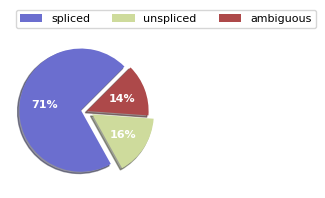

In [24]:
scv.pl.proportions(sample_use) # 剪切比例可视化

饼图展示拼接计数/非拼接计数的比例。不同的测序方案（Drop-Seq、Smart Seq）都会获得 10%-25%的非重复内含子序列比例。比例符合预期：在循环导管细胞中非剪切比例略低，在 Ngn3-high 和内分泌前细胞中非剪切比例偏高(表示许多基因开始转录)。

In [25]:
## run scvelo
# Basic preprocessing
scv.pp.filter_and_normalize(sample_use)
scv.pp.moments(sample_use)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_26258/2052862893.py:4: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(sample_use)
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed

computing neighbors
    finished (0:00:19) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:22) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [26]:
print(sample_use.layers.keys())

KeysView(Layers with keys: matrix, ambiguous, spliced, unspliced, Ms, Mu)


In [27]:
# Velocity Tools 速率推断
scv.tl.velocity(sample_use, mode = "deterministic") #dynamical
#scv.tl.velocity(sample_use, mode = "stochastic")
scv.tl.velocity_graph(sample_use)
# 计算出的速率值存储在 adata.layers 中，类似于 count 矩阵。

computing velocities
    finished (0:02:46) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/96 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:25) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


速率是基因表达的载体，并表征单个细胞运动的方向和速率。速率是通过模拟剪接动力学的转录动力学模型获得，要么是随机的(默认)，要么是确定性的(通过设置 mode='deterministic'调整模型)。拟合每个基因的预成熟(未剪接)和成熟(剪接)mRNA 比例，这就构成了一个恒定的转录状态。然后，通过残差获得速率。正速率表示基因上调，这种情况发生在细胞中，该基因的未剪接 mRNA 的丰度高于稳定状态下的预期。相反，负速度表示基因被下调。  
考量每个基因的速率就可以用来估计单个细胞的未来状态。为了将速率投射到低维状态，估算了细胞到细胞间的转移概率。也就是说，对于每一个速率矢量，我们都能找到与那个方向一致的可能的细胞转移。转换概率是利用潜在的细胞间转换和速率矢量之间的余弦相关性计算的，并存储在一个表示为速率图的矩阵中。

computing velocity embedding
    finished (0:00:09) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-pa

saving figure to file ./figures/scvelo_scvelo_sample.pdf


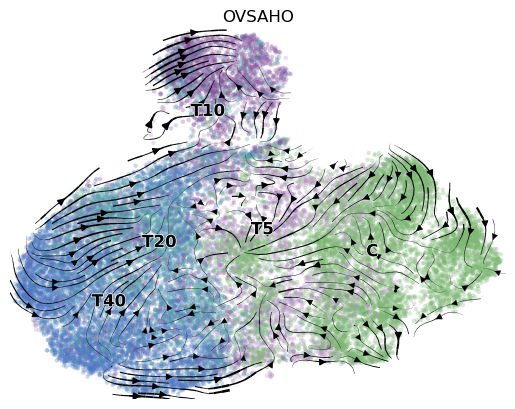

/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-pa

saving figure to file ./figures/scvelo_scvelo_sample2.pdf


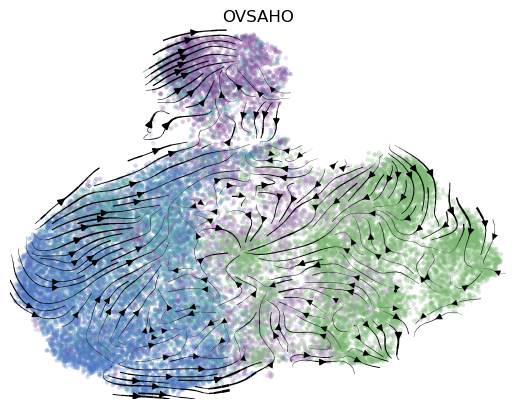

In [28]:
# Visualization
#plot_color = list(custer_color["color"])
sample_color = {"C": "#7EB875","T5": "#B997C7","T10": "#824D99","T20": "#57A2AC","T40": "#4E78C4"}
#scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_sample",palette=sample_color,fontsize=8,legend_fontsize=8,min_mass=2,title="COV362",dpi=300,save="scvelo_sample.png")
scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_sample",palette=sample_color,fontsize=12,legend_fontsize=12,min_mass=2,title="OVSAHO",save="scvelo_sample.pdf")
scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_sample",palette=sample_color,fontsize=12,legend_fontsize=12,min_mass=2,title="OVSAHO",save="scvelo_sample2.pdf",legend_loc="none")


/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-pa

saving figure to file ./figures/scvelo_scvelo_clusters.pdf


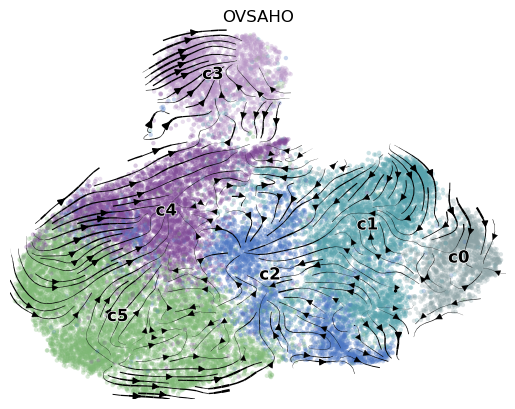

/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/user_yan/mambaforge/envs/pyvelocyto/lib/python3.9/site-pa

saving figure to file ./figures/scvelo_scvelo_clusters2.pdf


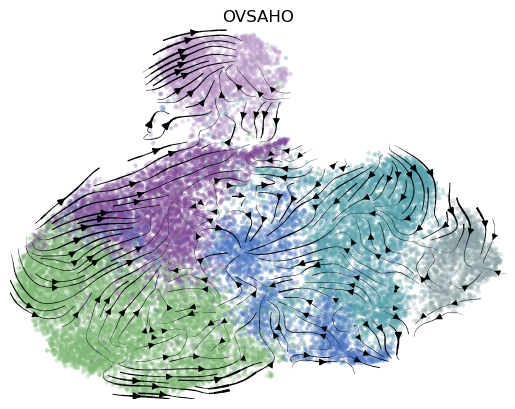

In [29]:
# Visualization
#plot_color = list(custer_color["color"])
sample_color = {"c0": "#8DA3A6","c1": "#57A2AC","c2": "#4E78C4","c3": "#B997C7","c4": "#824D99","c5": "#7EB875"}
#scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_sample",palette=sample_color,fontsize=8,legend_fontsize=8,min_mass=2,title="COV362",dpi=300,save="scvelo_sample.png")
scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_clusters",palette=sample_color,fontsize=12,legend_fontsize=12,min_mass=2,title="OVSAHO",save="scvelo_clusters.pdf")
scv.pl.velocity_embedding_stream(sample_use, basis='umap',color="cell_clusters",palette=sample_color,fontsize=12,legend_fontsize=12,min_mass=2,title="OVSAHO",save="scvelo_clusters2.pdf",legend_loc="none")

In [ ]:
# 可视化
scv.pl.velocity_embedding_grid(sample_use,basis="umap",color="cell_clusters",title='A2780',fontsize=20,legend_fontsize=20,min_mass=2,color_map="plasma",save='scVelo-umap-grid.pdf')
scv.pl.velocity_embedding_stream(sample_use,basis="umap",color="cell_clusters",title='A2780',fontsize=12,legend_fontsize=12,min_mass=2,color_map="plasma",save='scVelo-umap-stream.png')

In [ ]:
scv.pl.velocity_embedding(sample_use, color="cell_clusters", arrow_length=3, arrow_size=2, dpi=120)